In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.transforms import transforms
from torchvision import datasets
from torch.utils.data import DataLoader,random_split

In [7]:
device = torch.device('cpu')

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [10]:
dataset = datasets.ImageFolder(r'D:\Dl\PYTORCH_PROJECT_05\fire_dataset', transform=transform)

In [11]:
train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

In [12]:
print(dataset.classes)        # should show ['Fire_image', 'Non_Fire_image'] (or your folder names)
print(len(train_data), len(test_data))
images, labels = next(iter(train_loader))
print(images.shape)           # torch.Size([32, 3, 224, 224])

['fire_images', 'non_fire_images']
699 300
torch.Size([128, 3, 224, 224])


In [17]:
class fire(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.features = nn.Sequential(
            nn.Conv2d(3,8,3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(8,16,3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        
        
        self.Classifier = nn.Sequential(
            nn.Linear(16*56*56,128),
            nn.ReLU(),
            nn.Linear(128,2)
        )
        
        
    def forward(self,x):
        x = self.features(x)
        x = x.view(x.size(0),-1)
        x = self.Classifier(x)
        return x
        
        
model = fire().to(device)

Optimizer = optim.Adam(model.parameters(),lr=0.001)

loss_fn = nn.CrossEntropyLoss()


epochs = 5
Total_loss = []
Avg_loss = []
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        Optimizer.zero_grad()
        loss = loss_fn(output,labels)
        loss.backward()
        Optimizer.step()
        
        total_loss += loss.item()
        avg_loss = total_loss/len(train_loader)
        
    Total_loss.append(total_loss)
    Avg_loss.append(avg_loss)
    print(f'Epochs no : {epoch+1}/{epochs} | Loss : {total_loss}')
    
    
    
model.eval()
total = 0
correct = 0
for images,labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    output = model(images)
    predict = output.argmax(dim=1)
    
    correct += (predict == labels).sum().item()
    total += labels.size(0)
accuracy = 100*correct/total
print(f"Test Acc: {accuracy:.2f}%")

Epochs no : 1/5 | Loss : 7.400645345449448
Epochs no : 2/5 | Loss : 2.091430962085724
Epochs no : 3/5 | Loss : 1.547060027718544
Epochs no : 4/5 | Loss : 1.369905561208725
Epochs no : 5/5 | Loss : 1.0233300477266312
Test Acc: 91.00%


In [30]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

[[212  17]
 [ 10  61]]
                 precision    recall  f1-score   support

    fire_images       0.95      0.93      0.94       229
non_fire_images       0.78      0.86      0.82        71

       accuracy                           0.91       300
      macro avg       0.87      0.89      0.88       300
   weighted avg       0.91      0.91      0.91       300



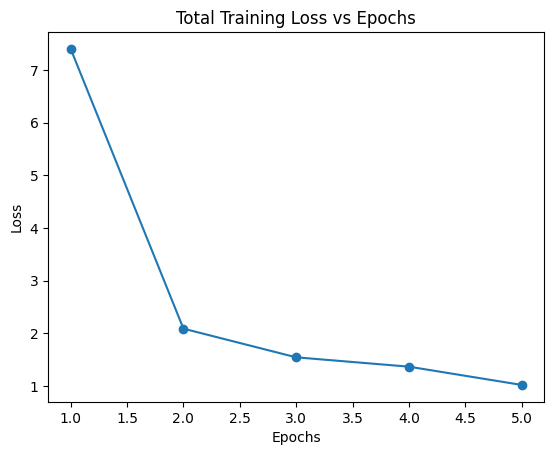

In [18]:
import matplotlib.pyplot as plt
plt.plot(range(1, epochs + 1), Total_loss, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Total Training Loss vs Epochs')
plt.show()

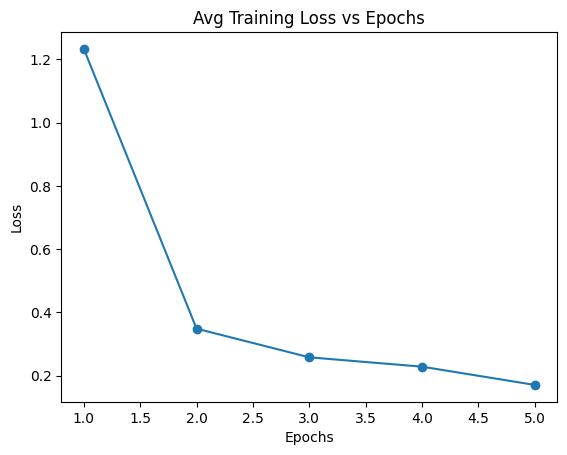

In [19]:
plt.plot(range(1, epochs + 1), Avg_loss, marker='o')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Avg Training Loss vs Epochs')


plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


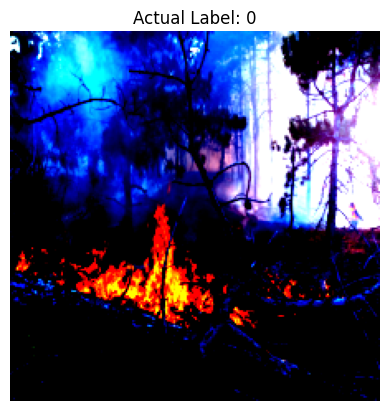

User Picked Index No: 50
Actual Label: 0
Predicted Label: 1


In [43]:
index = 50
image , label = test_data[index]

# Display RGB image
plt.imshow(image.permute(1, 2, 0))
plt.title(f'Actual Label: {label}')
plt.axis('off')
plt.show()

# Add batch dimension
# [3, 224, 224] → [1, 3, 224, 224]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image)
    predicted_label = output.argmax(dim=1).item()

print(f'User Picked Index No: {index}')
print(f'Actual Label: {label}')
print(f'Predicted Label: {predicted_label}')

# WE ARE USING PRE BUILT MODEL RESNET18 ON THIS DATASET .

In [33]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)
resnet_model = resnet_model.to(device)

Optimizer = optim.Adam(resnet_model.parameters(), lr=0.0001)   # smaller lr for fine-tuning
loss_fn = nn.CrossEntropyLoss()

In [ ]:
epochs = 5
Total_loss = []
Avg_loss = []
for epoch in range(epochs):
    resnet_model.train()
    total_loss = 0
    
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = resnet_model(images)
        Optimizer.zero_grad()
        loss = loss_fn(output,labels)
        loss.backward()
        Optimizer.step()
        
        total_loss += loss.item()
        avg_loss = total_loss/len(train_loader)
        
    Total_loss.append(total_loss)
    Avg_loss.append(avg_loss)
    print(f'Epochs no : {epoch+1}/{epochs} | Loss : {total_loss}')
    
    
    

Epochs no : 1/5 | Loss : 2.5682172626256943
Epochs no : 2/5 | Loss : 0.4201345182955265
Epochs no : 3/5 | Loss : 0.10239666886627674
Epochs no : 4/5 | Loss : 0.04195663728751242
Epochs no : 5/5 | Loss : 0.022829440771602094
Test Acc: 91.00%


In [49]:
resnet_model.eval()
total = 0
correct = 0
with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = resnet_model(images)
        predict = output.argmax(dim=1)
        
        correct += (predict == labels).sum().item()
        total += labels.size(0)
accuracy = 100*correct/total
print(f"Test Acc: {accuracy:.2f}%")

Test Acc: 98.00%


In [35]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels = [], []
resnet_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        preds = resnet_model(images.to(device)).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

[[229   0]
 [  6  65]]
                 precision    recall  f1-score   support

    fire_images       0.97      1.00      0.99       229
non_fire_images       1.00      0.92      0.96        71

       accuracy                           0.98       300
      macro avg       0.99      0.96      0.97       300
   weighted avg       0.98      0.98      0.98       300



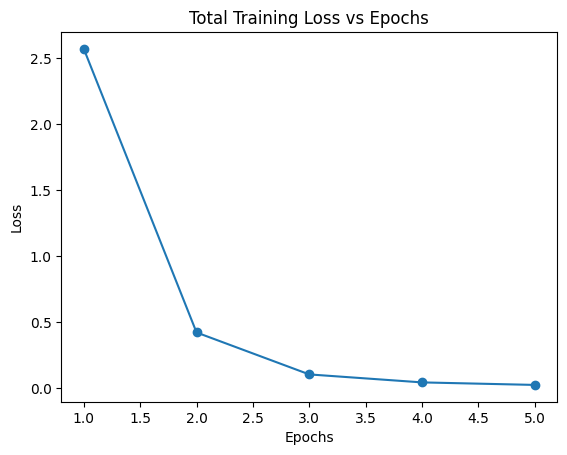

In [36]:
import matplotlib.pyplot as plt
plt.plot(range(1, epochs + 1), Total_loss, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Total Training Loss vs Epochs')
plt.show()

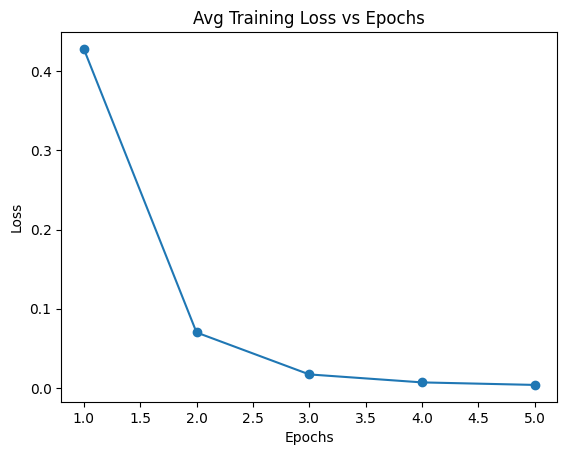

In [37]:
plt.plot(range(1, epochs + 1), Avg_loss, marker='o')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Avg Training Loss vs Epochs')


plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


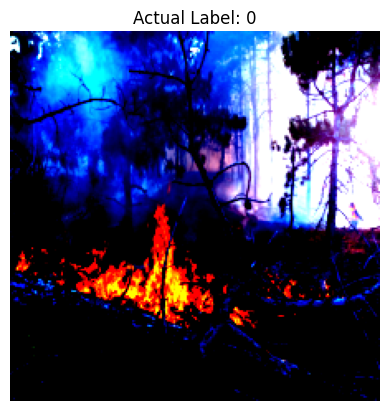

User Picked Index No: 50
Actual Label: 0
Predicted Label: 0


In [44]:
index = 50
image , label = test_data[index]

# Display RGB image
plt.imshow(image.permute(1, 2, 0))
plt.title(f'Actual Label: {label}')
plt.axis('off')
plt.show()

# Add batch dimension
# [3, 224, 224] → [1, 3, 224, 224]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = resnet_model(image)
    predicted_label = output.argmax(dim=1).item()

print(f'User Picked Index No: {index}')
print(f'Actual Label: {label}')
print(f'Predicted Label: {predicted_label}')

In [50]:
torch.save(resnet_model.state_dict(),'Fire_Detection_Resnet.pth')
print('Model is save')

Model is save


# MODEL TRANING ON MOBILENET 

In [ ]:
mobilenet_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
mobilenet_model.classifier[1] = nn.Linear(mobilenet_model.classifier[1].in_features, 2)
mobilenet_model = mobilenet_model.to(device)

Optimizer = optim.Adam(mobilenet_model.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()


epochs = 5
Total_loss = []
Avg_loss = []
for epoch in range(epochs):
    mobilenet_model.train()
    total_loss = 0
    
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = mobilenet_model(images)
        Optimizer.zero_grad()
        loss = loss_fn(output,labels)
        loss.backward()
        Optimizer.step()
        
        total_loss += loss.item()
        avg_loss = total_loss/len(train_loader)
        
    Total_loss.append(total_loss)
    Avg_loss.append(avg_loss)
    print(f'Epochs no : {epoch+1}/{epochs} | Loss : {total_loss}')
    
    
    
mobilenet_model.eval()
total = 0
correct = 0
with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = mobilenet_model(images)
        predict = output.argmax(dim=1)
        
        correct += (predict == labels).sum().item()
        total += labels.size(0)
accuracy = 100*correct/total
print(f"Test Acc: {accuracy:.2f}%")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\ADMIN/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100.0%


Epochs no : 1/5 | Loss : 0.014425909030251205
Epochs no : 2/5 | Loss : 0.014871983788907528
Epochs no : 3/5 | Loss : 0.01861363009084016
Epochs no : 4/5 | Loss : 0.016498583601787686
Epochs no : 5/5 | Loss : 0.017134229419752955
Test Acc: 91.00%


In [52]:
from sklearn.metrics import confusion_matrix, classification_report

# ... your training loop above, unchanged ...

mobilenet_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = mobilenet_model(images.to(device)).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

acc = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test Acc: {acc:.2f}%")
print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

Test Acc: 27.00%
[[ 53 176]
 [ 43  28]]
                 precision    recall  f1-score   support

    fire_images       0.55      0.23      0.33       229
non_fire_images       0.14      0.39      0.20        71

       accuracy                           0.27       300
      macro avg       0.34      0.31      0.26       300
   weighted avg       0.45      0.27      0.30       300



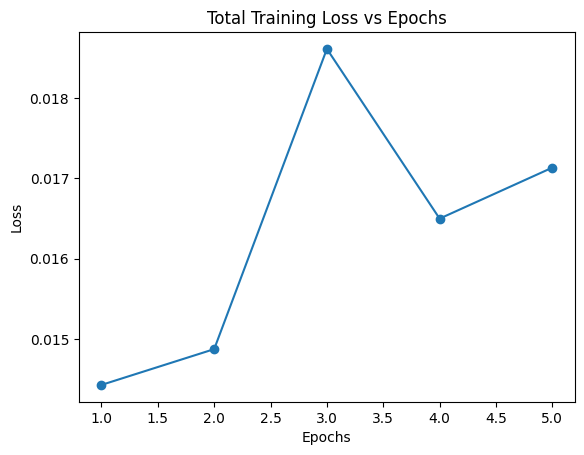

In [47]:
plt.plot(range(1, epochs + 1), Total_loss, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Total Training Loss vs Epochs')
plt.show()

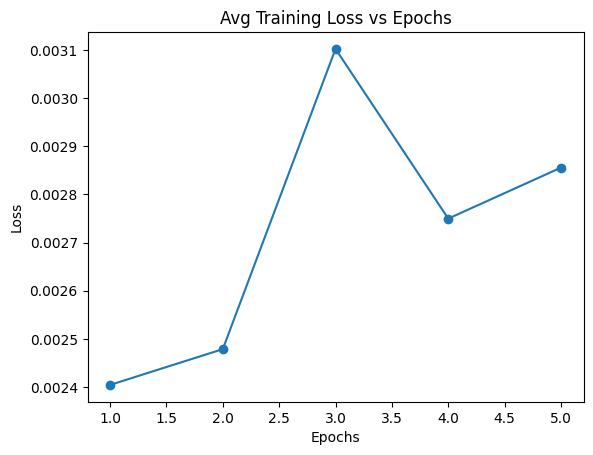

In [48]:
plt.plot(range(1, epochs + 1), Avg_loss, marker='o')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Avg Training Loss vs Epochs')


plt.show()

In [51]:
print(type(model))
print(type(mobilenet_model))
print(model is mobilenet_model)   # False means the loops trained something else

<class '__main__.fire'>
<class 'torchvision.models.mobilenetv2.MobileNetV2'>
False


In [56]:
dataset.class_to_idx

{'fire_images': 0, 'non_fire_images': 1}